# IMLO_Open Assesment
Y3921738

## Initialisation

### Imports 

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import torch.optim.lr_scheduler as Scheduler
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import ConcatDataset
import torchvision.models as models
import matplotlib.pyplot as plt

In [2]:
# expierencing issues with UserWarning: Plan failed with a cudnnException
import torch.backends.cudnn as cudnn
cudnn.enabled = False

### Hyper Parameters

In [3]:
# General Hyper Parameters
image_size = 224
batch_size = 16
epochs = 20
learning_rate = 4e-4
drop_out = 0.33

# Optimiser Parameters
sgd_momentum = 0.9
sgd_weight_decay = 7e-5
nesterov = False

# Scheduler Parameters
patience = 3
factor = 0.1
threshold = 1e-1
threshold_mode = "abs"
cooldown = 5

# Get the gpu invovled with calculation
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

# Where the model will be saved and loaded to
save_path = "./flowers-102.pth"

## Data Preprocessing

### Calculate mean and standard deviation of data
Code isnt currently used cause I only need to calculate it once but I have left in so you can see how I have got my mean and standard deviation

In [4]:
# base_transform = transforms.Compose([
#     transforms.Resize(size=(image_size, image_size)),
#     transforms.ToTensor()])

# base_data = datasets.Flowers102(root="data", split="train", transform=base_transform, download=True)
# base_dataloader = DataLoader(base_data, batch_size=batch_size)

# mean = 0
# std = 0
# total_images = len(base_dataloader.dataset)

# for images, _ in base_dataloader:
#     batch_size = images.size(0)  
#     images = images.view(batch_size, 3, -1)  
#     mean += images.mean(2).sum(0)  
#     std += images.std(2).sum(0)  


# mean /= total_images
# std /= total_images
# print(mean, std)

### Load and Transform Data

In [5]:
# Calculated above
mean = (0.4330, 0.3819, 0.2964)
std = (0.2588, 0.2094, 0.2211)

# Base transforms
base_transform = transforms.Compose([
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor()])

# Variations in angle as flowers can appear in nature in many orientations
train_transform1 = transforms.Compose([
    transforms.RandomRotation(degrees=90),  
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),  
    transforms.Normalize(mean, std)  
])

# Same basis as 1 but different transformations
train_transform2 = transforms.Compose([
    transforms.RandomVerticalFlip(),
    transforms.RandomHorizontalFlip(), 
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),  
    transforms.Normalize(mean, std)  
])

# Variations in colour as flowers can appear in many colours 
train_transform3 = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3), 
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),  
    transforms.Normalize(mean, std)  
])

# Same as 3 but randomly apply the colour jitter with a higher factor but 50% probability also split the changes up.
train_transform4 = transforms.Compose([
    transforms.RandomApply([transforms.ColorJitter(brightness=0.5)], p=0.5),
    transforms.RandomApply([transforms.ColorJitter(contrast=0.5)], p=0.5),
    transforms.RandomApply([transforms.ColorJitter(saturation=0.5)], p=0.5),
    transforms.RandomApply([transforms.ColorJitter(hue=0.5)], p=0.5),
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),  
    transforms.Normalize(mean, std)  
])

# Grey scale to help the model train on structure as well as colour
train_transform5 = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),  
    transforms.Normalize(mean, std)  
])

# Random crop for helping with generalisation
train_transform6 = transforms.Compose([
    transforms.RandomResizedCrop(size=(image_size, image_size)),
    transforms.ToTensor(),  
    transforms.Normalize(mean, std)  
])

# Random perspectives as photos
train_transform7 = transforms.Compose([
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5, interpolation=3),
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),  
    transforms.Normalize(mean, std)  
])

# Combination of perspective changes: translation, rotation, scaling, and shearing
train_transform8 = transforms.Compose([
    transforms.RandomAffine(degrees=30, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=5),
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Combination of colour and perspective shift
train_transform9 = transforms.Compose([
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5, interpolation=3),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3), 
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Random cropping with colour jitter 
train_transform10 = transforms.Compose([
    transforms.RandomResizedCrop(size=(image_size, image_size)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3), 
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])



validation_data = datasets.Flowers102(root="data", split="val", transform=base_transform, download=True)
test_data = datasets.Flowers102(root="data", split="test", transform=base_transform, download=True)
training_data = datasets.Flowers102(root="data", split="train", transform=base_transform, download=True)

for i in range(1):
    augmented1 = datasets.Flowers102(root="data", split="train", transform=train_transform1)
    augmented2 = datasets.Flowers102(root="data", split="train", transform=train_transform2)
    augmented3 = datasets.Flowers102(root="data", split="train", transform=train_transform3)
    augmented4 = datasets.Flowers102(root="data", split="train", transform=train_transform4)
    augmented5 = datasets.Flowers102(root="data", split="train", transform=train_transform5)
    augmented6 = datasets.Flowers102(root="data", split="train", transform=train_transform6)
    augmented7 = datasets.Flowers102(root="data", split="train", transform=train_transform7)
    augmented8 = datasets.Flowers102(root="data", split="train", transform=train_transform8)
    augmented9 = datasets.Flowers102(root="data", split="train", transform=train_transform9)
    augmented10 = datasets.Flowers102(root="data", split="train", transform=train_transform10)
    training_data = ConcatDataset([training_data, augmented1, augmented2, augmented3, augmented4, augmented5, augmented6, augmented7, augmented8, augmented9, augmented10])

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)
validation_dataloader = DataLoader(validation_data, batch_size=batch_size)

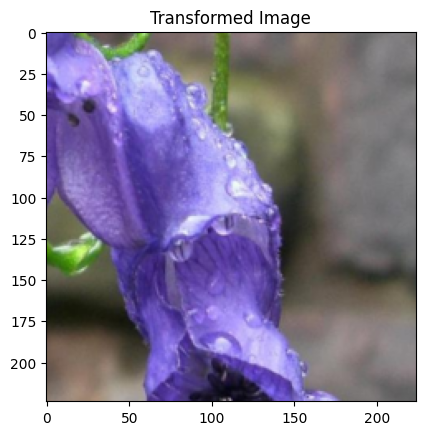

In [6]:
affine_load = transforms.Compose([
    transforms.RandomResizedCrop(size=(image_size, image_size)),
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),
    # transforms.Normalize(mean, std)
])

train_dataset = datasets.Flowers102(root="data", split="train", transform=affine_load, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Visualize an example transformed image
for images, _ in train_loader:
    transformed_image = transforms.ToPILImage()(images[0])  # Convert the first image tensor to PIL image
    plt.imshow(transformed_image)
    plt.title('Transformed Image')
    plt.show()
    break  # Break after visualizing one transformed image

## Neural Network

### Base Network Class

In [7]:
class ConvNetwork(nn.Module):
    """
    A class that represents a convolutional neural network.
    ...
    Methods:
        forward (x): Takes the input x and computes the output from the network
    """
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        conv_output_size = image_size // 4  # assuming image_size is divisible by 16
        flattened_size = conv_output_size * conv_output_size * 128  # 256 is the number of filters in the last conv layer
        self.conv_stack = nn.Sequential(
            # Block 1 =============================
            # Conv layer 1
            nn.Conv2d(3, 64, 9, padding=4),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(drop_out),
            
            nn.MaxPool2d(2, 2), # half dimensions
            
            # Block 2 =============================
            # Conv layer 2
            nn.Conv2d(64, 128, 5, padding=3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(drop_out),
            
            # Max Pooling 1 
            nn.MaxPool2d(3, 2), # half dimensions
            
            # Block 3 =============================
            # Conv layer 3
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(drop_out),
            
            # Conv layer 4
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(drop_out),
            
            # Max Pooling
            nn.MaxPool2d(3, 2), # half dimensions
            
            # Block 4 =============================
            # Conv layer 5
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(drop_out),
            
            # Conv layer 6
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(drop_out),
            
            # Max Pooling
            nn.MaxPool2d(3, 2), # half dimensions  
            
            # Block 5 =============================
            # Conv layer 7
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(drop_out),
            
            # Conv layer 8
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(drop_out),
            
            # Max Pooling
            nn.MaxPool2d(3, 2) # half dimensions     
        )
    
        self.linear_relu_stack = nn.Sequential(
            # Linear layer 1
            nn.Linear(4608, 256), # image size -12 squared, for the conv and pool (image_size - 12)*(image_size - 12)
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(drop_out),
            # Linear layer 2
            # nn.Linear(512, 512),
            # nn.BatchNorm1d(512),
            # nn.ReLU(),
            # nn.Dropout(drop_out),
            # Out layer
            nn.Linear(256, 102)
        )

    def forward(self, x):
        """
        Takes input x and returns the output of the network
        ...
        Parameters:
            x (Torch Tensor): the input
        Returns:
            x (Torch Tensor): output of network
        """
        x = self.conv_stack(x)
        x = self.flatten(x)
        out = self.linear_relu_stack(x)
        return out


### AlexNet Inspired

In [8]:
class AlexStyleNetwork(nn.Module):
    """
    A class that represents a AlexNet Style neural network.
    ...
    Methods:
        forward (x): Takes the input x and computes the output from the network
    """
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        flattened_size = 2048 
        # Stack of convolutional layers to get features from the images
        self.feature_extraction = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 128, kernel_size=9, padding=4, stride=3),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Dropout(drop_out),
   
    
            # Conv Block 2
            nn.Conv2d(128, 256, kernel_size=5, padding=2, stride=2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Dropout(drop_out),
     

            # Conv Block 3
            nn.Conv2d(256, 256, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Dropout(drop_out),
        
    
        )
    
        # Stack of linear layers that acts as a classifier on the features we created
        self.classification = nn.Sequential(
            # Linear layer 1
            nn.Linear(flattened_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(drop_out),
            # Out layer
            nn.Linear(256, 102)
        )

    def forward(self, x):
        """
        Takes input x and returns the output of the network
        ...
        Parameters:
            x (Torch Tensor): the input
        Returns:
            x (Torch Tensor): output of network
        """
        x = self.feature_extraction(x)
        x = self.flatten(x)
        out = self.classification(x)
        return out

### Generate Instance

In [9]:
classifier = ConvNetwork().to(device)
# classifier.load_state_dict(torch.load(save_path)) # This is optional and lets us load a saved model we have trained before
# print(classifier)

# Training

### Training Parameters

In [10]:
loss_fn = nn.CrossEntropyLoss()

# still look at new optimisers
optimizer1 = torch.optim.SGD(classifier.parameters(), lr=learning_rate, momentum=sgd_momentum, weight_decay=sgd_weight_decay, nesterov=nesterov)
optimizer2 = torch.optim.AdamW(classifier.parameters(), lr=learning_rate, weight_decay=sgd_weight_decay)

optimizer = optimizer1

# 
scheduler1 = Scheduler.ReduceLROnPlateau(optimizer=optimizer, patience=patience, factor=factor, threshold=threshold, threshold_mode=threshold_mode, cooldown=cooldown)
scheduler2 = Scheduler.CosineAnnealingLR(optimizer, T_max=10)

scheduler = scheduler1

### Training, Validation and Testing Loops

In [11]:
def train_loop(dataloader, classifier, loss_fn, optimizer):
    losses = 0
    classifier.train()
    batches_ran = 0
    size = len(dataloader.dataset)
    
    for batch, (X, y) in enumerate(dataloader):
        y_pred = classifier(X.to(device))
        loss = loss_fn(y_pred, y.to(device))
        losses += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batches_ran += 1
        if batch % 100 == 0:
            print(end="|")
    avg_loss = losses/batches_ran
    print(" Training Loop Done")
    return avg_loss

# This can also act as the loop for testing if we load the testing data loader
def validation_loop(dataloader, classifier, loss_fn):
    classifier.eval()
    size = len(dataloader.dataset)
    loss = 0
    accuracy = 0

    with torch.no_grad():
        for (X, y) in dataloader:
            y_pred = classifier(X.to(device))
            loss += loss_fn(y_pred, y.to(device)).item()
            accuracy += (y_pred.argmax(1) == y.to(device)).type(torch.float).sum().item()

    loss /= len(dataloader)
    accuracy = (accuracy / size) * 100
    return accuracy, loss


### Run Classifier on Training and Validation Data

In [12]:
train_losses, val_accuracies, val_losses = [], [], []
print(f"Using {device} device")
for i in range(epochs):
    print(f"Epoch {i+1}: ",  end="")
    train_loss = train_loop(train_dataloader, classifier, loss_fn, optimizer)
    val_accuracy, val_loss = validation_loop(validation_dataloader, classifier, loss_fn)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_accuracies.append(val_accuracy)
    val_losses.append(val_loss)
    print(f"Training Avg Loss: {train_loss:>8f} | Validation Avg Loss: {val_loss:>8f} | Validation Accuracy: {(val_accuracy):>0.3f}% | Learning rate: {scheduler.get_last_lr()}")
    torch.cuda.synchronize()
print("Finished Training")

Using cuda device
Epoch 1: 

RuntimeError: mat1 and mat2 shapes cannot be multiplied (16x4608 and 6272x256)

# Testing And Evaluation

### Testing Data

In [ ]:
print("Testing:")
test_accuracy, test_loss = validation_loop(test_dataloader, classifier, loss_fn)
print(f"Loss: {test_loss} | Accuracy: {test_accuracy} on {len(test_dataloader.dataset)} data points")

Testing:
Loss: 1.9083410297121322 | Accuracy: 51.48804683688405 on 6149 data points


c:\Users\elija\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


### Graph Data

Highest Accuracy: 55.98


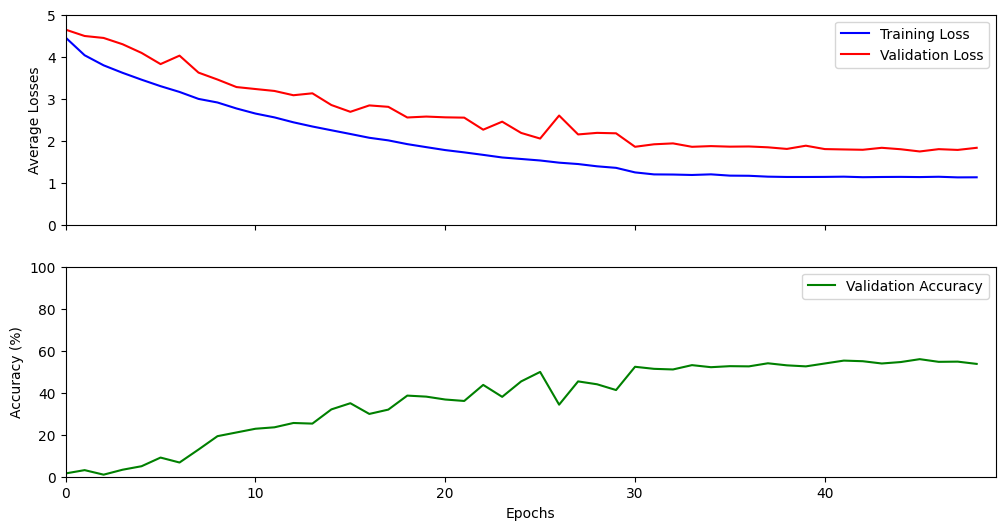

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(12,6), sharex=True)
ax1.axis([0, len(val_losses), 0, 5])
ax1.plot(range(len(train_losses)), train_losses, color="blue", label="Training Loss")
ax1.plot(range(len(val_losses)), val_losses, color="red", label="Validation Loss")
ax1.set(ylabel='Average Losses')
ax1.legend()
ax2.axis([0, len(val_accuracies), 0, 100])
ax2.plot(range(len(val_accuracies)), val_accuracies, color="green", label="Validation Accuracy")
ax2.set(xlabel='Epochs', ylabel='Accuracy (%)')
ax2.legend()
print(f"Highest Accuracy: {(max(val_accuracies)):>0.2f}")

# Save the model

In [ ]:
# model = models.vgg16(weights='IMAGENET1K_V1')
# torch.save(model.state_dict(), save_path)